# En 2024, Ecuador apagó las luces. Hasta 12 horas al día.

El 70% de su electricidad viene de represas. Cuando dos temporadas de lluvia consecutivas fallaron, los ríos se secaron y los embalses casi se vaciaron. ¿La solución? Justo lo que muchos critican por "poco confiable": solar y eólica.

---

📄 **Paper:** Sterl, S., Pineda, L.E., et al. *Variable renewables fortify Ecuador's power system against recurrences of drought-driven energy crises.* Nature Water (2026).
DOI: [10.1038/s44221-026-00617-w](https://doi.org/10.1038/s44221-026-00617-w)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-04-07-renovables-fortalecen-ecuador-sequia/notebook.ipynb)

🎬 **Video:** [Pendiente]

## El experimento natural más caro de Sudamérica

Ecuador apostó todo al agua. Su sistema eléctrico creció de 6 GW en 2015 a 9 GW en 2025, mayormente construyendo represas. El corazón del sistema es el Complejo Paute: tres plantas en cascada (Mazar, Paute Molino y Sopladora) con 1.757 MW de capacidad.

En 2023, el río Paute empezó a bajar. En 2024, colapsó. El gobierno tuvo que decretar apagones diarios de hasta 12 horas para evitar que los embalses se vaciaran por completo — lo que la prensa ecuatoriana llamó "volver al siglo XVIII".

Veamos qué dicen los datos hidrológicos de 14 años (2011-2024) y los factores de capacidad de solar y eólica para Ecuador.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
ANIO_CRISIS = 2024              # Año de la sequía principal
ANIO_PREVIO = 2023              # Inicio de la sequía
HIST_INICIO = 2011              # Inicio del periodo histórico
HIST_FIN = 2022                 # Fin del periodo histórico (pre-crisis)
CAPACIDAD_SOLAR_MW = 613        # Escenario S4 del paper (MW)
CAPACIDAD_EOLICA_MW = 613       # Escenario S4 del paper (MW)
FUENTE = 'Fuente: Sterl et al. (2026), Nature Water | Datos: Zenodo (10.5281/zenodo.15854447)'

COLOR_HIDRO = '#2563EB'         # Azul CaM — datos hídricos
COLOR_ALERTA = '#DC2626'        # Rojo — crisis/déficit
COLOR_SOLAR = '#D97706'         # Amber — energía solar
COLOR_EOLICA = '#059669'        # Emerald — energía eólica
COLOR_HIST = '#BBBBBB'          # Gris — histórico/referencia

# ══════════════════════════════════════════════════════════════
# Setup
# ══════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os, urllib.request

# Estilo CaM
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve('https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle', style_file)
plt.style.use(style_file)

# Cargar datos
df_paute = pd.read_csv('datos/caudal_mensual_paute.csv')
df_re = pd.read_csv('datos/factores_capacidad_mensual.csv')
df_anual = pd.read_csv('datos/caudal_anual_paute.csv')

# Renombrar meses al español
MESES = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

# Resumen
n_anios = df_paute.year.nunique()
media_hist = df_paute[df_paute.year <= HIST_FIN].inflow_m3s.mean()
media_crisis = df_paute[df_paute.year == ANIO_CRISIS].inflow_m3s.mean()
deficit_pct = (media_crisis - media_hist) / media_hist * 100

print(f"Datos cargados: {n_anios} años ({HIST_INICIO}-{ANIO_CRISIS})")
print(f"Río Paute — media histórica: {media_hist:.1f} m³/s")
print(f"Río Paute — media {ANIO_CRISIS}: {media_crisis:.1f} m³/s ({deficit_pct:+.1f}%)")
print(f"Solar CF promedio: {df_re.solar_cf.mean()*100:.1f}%")
print(f"Wind CF promedio: {df_re.wind_cf.mean()*100:.1f}%")

Datos cargados: 14 años (2011-2024)
Río Paute — media histórica: 129.4 m³/s
Río Paute — media 2024: 74.5 m³/s (-42.4%)
Solar CF promedio: 18.9%
Wind CF promedio: 53.6%


## 14 años de agua en el río Paute

Esto es lo que le pasó al río que mantiene encendido a Ecuador.

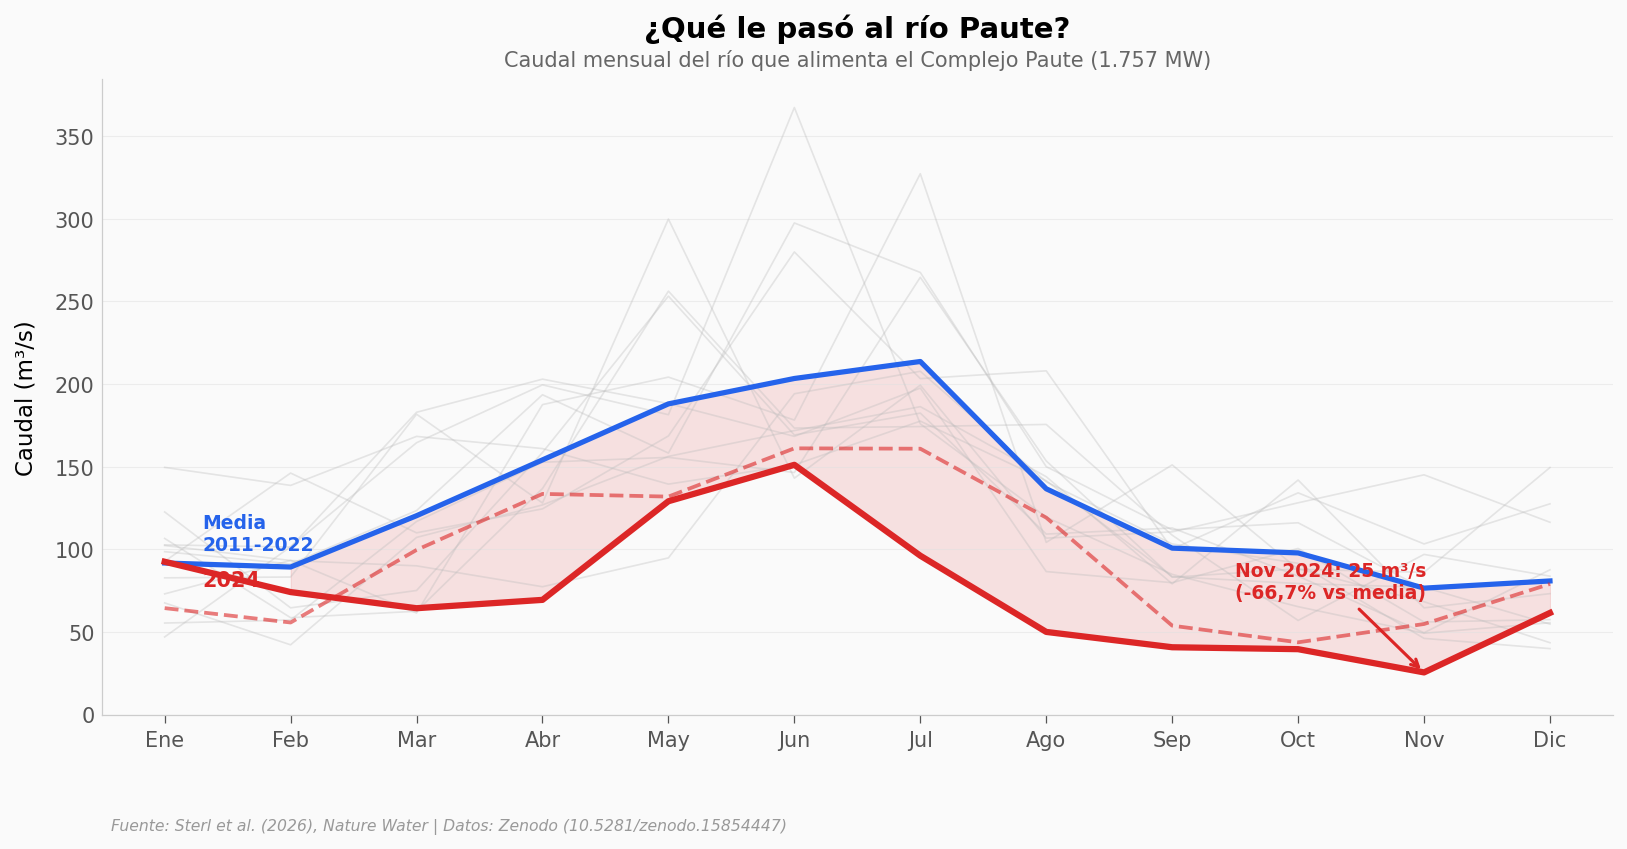

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

# Histórico: cada año como línea gris sutil
for y in range(HIST_INICIO, HIST_FIN + 1):
    dy = df_paute[df_paute.year == y]
    ax.plot(dy.month.values, dy.inflow_m3s.values, color=COLOR_HIST, alpha=0.35, linewidth=0.8)

# Media histórica
clim = df_paute[df_paute.year <= HIST_FIN].groupby('month').inflow_m3s.mean()
ax.plot(clim.index, clim.values, color=COLOR_HIDRO, linewidth=2.5, label='Media 2011-2022')

# 2023: primer año de sequía
dy23 = df_paute[df_paute.year == ANIO_PREVIO]
ax.plot(dy23.month.values, dy23.inflow_m3s.values, color=COLOR_ALERTA, linewidth=1.8,
        alpha=0.6, linestyle='--', label='2023')

# 2024: colapso
dy24 = df_paute[df_paute.year == ANIO_CRISIS]
ax.plot(dy24.month.values, dy24.inflow_m3s.values, color=COLOR_ALERTA, linewidth=3, label='2024')

# Sombrear el déficit entre media y 2024
ax.fill_between(clim.index, clim.values, dy24.inflow_m3s.values,
                where=clim.values > dy24.inflow_m3s.values,
                color=COLOR_ALERTA, alpha=0.12)

# Marcar noviembre 2024 (peor mes: -66,7%)
nov_hist = clim.loc[11]
nov_2024 = dy24[dy24.month == 11].inflow_m3s.values[0]
ax.annotate(f'Nov 2024: {nov_2024:.0f} m³/s\n(-66,7% vs media)',
            xy=(11, nov_2024), xytext=(9.5, nov_2024 + 45),
            fontsize=9, color=COLOR_ALERTA, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.5))

# Inline labels
ax.text(1.3, clim.loc[1] + 8, 'Media\n2011-2022', fontsize=9,
        color=COLOR_HIDRO, fontweight='bold')
ax.text(1.3, dy24[dy24.month == 1].inflow_m3s.values[0] - 15, '2024',
        fontsize=10, color=COLOR_ALERTA, fontweight='bold')

ax.set_xticks(range(1, 13))
ax.set_xticklabels(MESES)
ax.set_ylabel('Caudal (m³/s)', fontsize=11)
ax.set_title('¿Qué le pasó al río Paute?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Caudal mensual del río que alimenta el Complejo Paute (1.757 MW)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlim(0.5, 12.5)
ax.set_ylim(0, None)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/caudal_paute_crisis.png', dpi=200, bbox_inches='tight')
plt.show()

La zona rosa es agua que no llegó — y sin agua, no hay electricidad. En noviembre de 2024, el Paute llevaba apenas 25 m³/s — un tercio de lo normal. Ocho de los doce meses tuvieron déficits superiores al 30%, con agosto y noviembre cayendo más del 60% por debajo del promedio, y septiembre y octubre cerca del 60% (-59,6%).

Y la sequía no llegó de golpe. En 2023 el caudal ya había caído un 25,5%. Pero 2024 fue peor: -42,4% respecto al promedio histórico. El embalse no tuvo tiempo de recuperarse entre un año malo y otro peor.

## La pregunta: ¿había alternativa?

Mientras el río se secaba, ¿qué hacían el sol y el viento en Ecuador? Veamos cuánto genera cada fuente mes a mes.

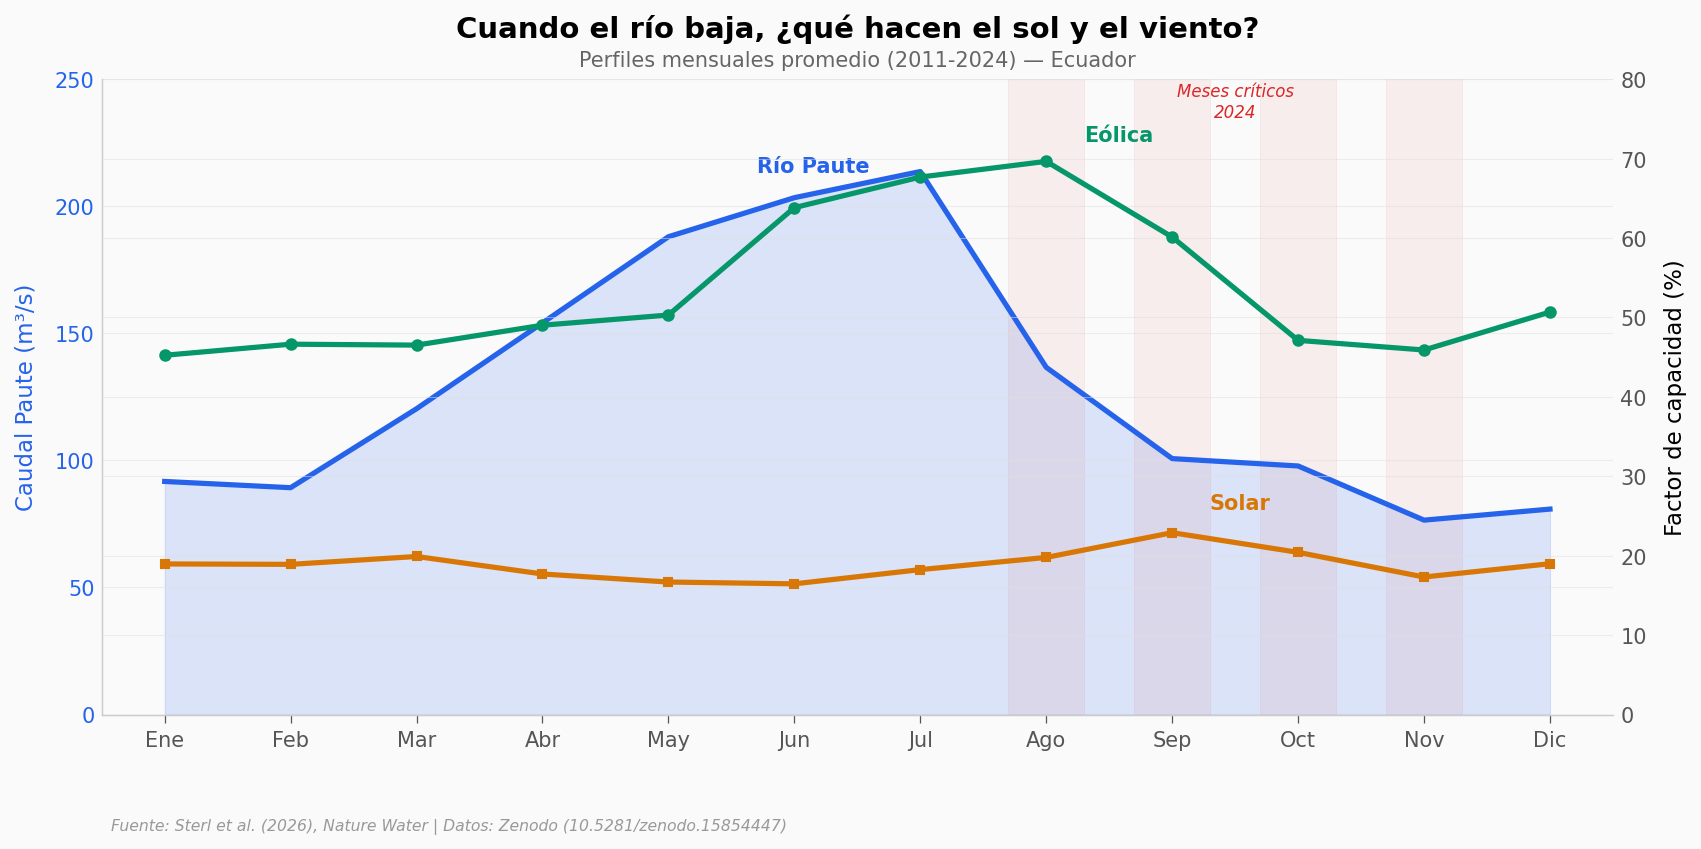

In [3]:
fig, ax1 = plt.subplots(figsize=(13, 5.5))

# Caudal del Paute (eje izquierdo)
clim_paute = df_paute[df_paute.year <= HIST_FIN].groupby('month').inflow_m3s.mean()
ax1.fill_between(clim_paute.index, 0, clim_paute.values, color=COLOR_HIDRO, alpha=0.15)
line_hidro, = ax1.plot(clim_paute.index, clim_paute.values, color=COLOR_HIDRO, linewidth=2.5)
ax1.set_ylabel('Caudal Paute (m³/s)', fontsize=11, color=COLOR_HIDRO)
ax1.tick_params(axis='y', labelcolor=COLOR_HIDRO)
ax1.set_ylim(0, 250)

# CFs de renovables (eje derecho)
ax2 = ax1.twinx()
clim_solar = df_re.groupby('month').solar_cf.mean() * 100
clim_wind = df_re.groupby('month').wind_cf.mean() * 100

line_wind, = ax2.plot(clim_wind.index, clim_wind.values, color=COLOR_EOLICA, linewidth=2.5,
        linestyle='-', marker='o', markersize=5)
line_solar, = ax2.plot(clim_solar.index, clim_solar.values, color=COLOR_SOLAR, linewidth=2.5,
        linestyle='-', marker='s', markersize=4)
ax2.set_ylabel('Factor de capacidad (%)', fontsize=11)
ax2.set_ylim(0, 80)

# Inline labels
ax2.text(8.3, clim_wind.loc[8] + 2.5, 'Eólica', fontsize=10,
         color=COLOR_EOLICA, fontweight='bold')
ax2.text(9.3, clim_solar.loc[9] + 3, 'Solar', fontsize=10,
         color=COLOR_SOLAR, fontweight='bold')
ax1.text(5.7, clim_paute.loc[6] + 10, 'Río Paute', fontsize=10,
         color=COLOR_HIDRO, fontweight='bold')

# Destacar meses de crisis (ago-nov)
for m in [8, 9, 10, 11]:
    ax1.axvspan(m - 0.3, m + 0.3, color=COLOR_ALERTA, alpha=0.06)
ax1.text(9.5, 235, 'Meses críticos\n2024', fontsize=8, color=COLOR_ALERTA,
         ha='center', style='italic')

ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(MESES)
ax1.set_title('Cuando el río baja, ¿qué hacen el sol y el viento?',
              fontsize=14, fontweight='bold', pad=20)
ax1.text(0.5, 1.02, 'Perfiles mensuales promedio (2011-2024) — Ecuador',
         transform=ax1.transAxes, fontsize=10, color='#666666', ha='center')
ax1.set_xlim(0.5, 12.5)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/complementariedad_mensual.png', dpi=200, bbox_inches='tight')
plt.show()

La eólica alcanza su pico justamente cuando el hidro empieza a debilitarse: 69,7% de factor de capacidad en agosto, cuando el Paute ya baja a 136,6 m³/s — un 36% menos que su pico de julio (213,7 m³/s). La correlación climatológica Paute-viento es positiva (ρ = +0,594, p = 0,04, n = 12 meses) porque ambos comparten la estación húmeda — pero eso esconde lo más importante.

Lo que importa no es el patrón estacional, sino lo que pasa cuando un año sale mal. En el dataset, los factores de capacidad del viento y el sol son los mismos cada año — porque usan datos de un año meteorológico típico (TMY), no mediciones anuales. Pero el argumento de fondo se sostiene: sol y viento no dependen de la lluvia. Si Ecuador hubiera tenido parques eólicos y solares, habrían seguido generando mientras los embalses se vaciaban.

Esto es lo que el paper llama **sinergia de año extremo** (*extreme-year synergy*): la complementariedad que aparece precisamente cuando más se necesita.

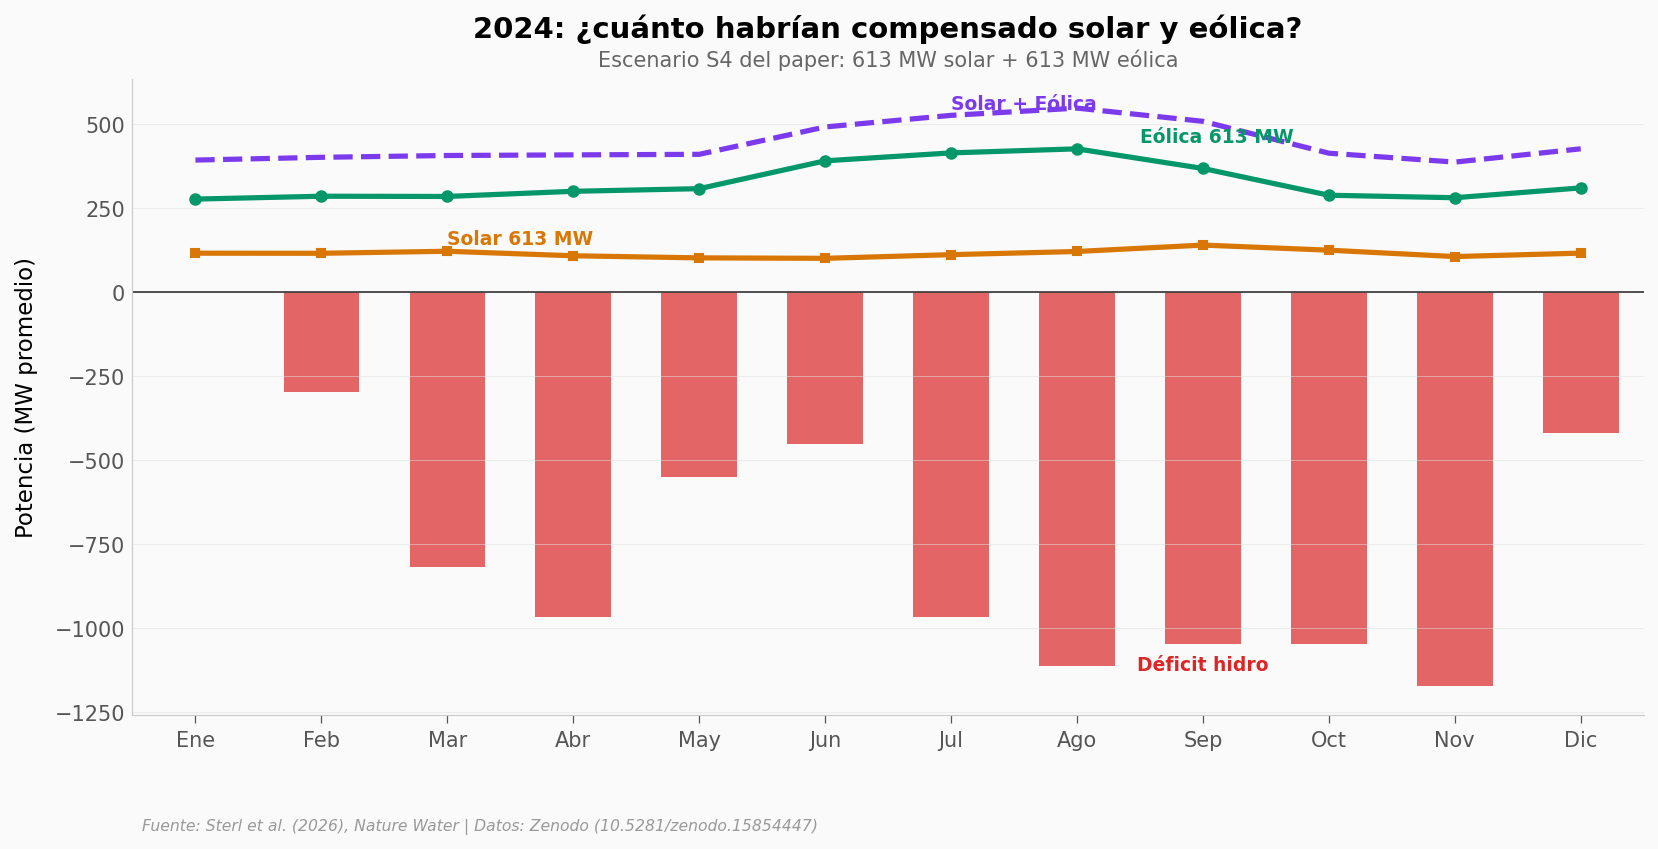

In [4]:
fig, ax = plt.subplots(figsize=(13, 5.5))

# Calcular déficit mensual de 2024 en MW equivalentes
# Potencia ~ caudal × cabeza × eficiencia × g × ρ (simplificado: proporcional al caudal)
# El Complejo Paute tiene 1.757 MW a caudal nominal (~200 m³/s promedio histórico máximo)
# Usamos la fracción de caudal perdido como proxy de MW perdidos
clim = df_paute[df_paute.year <= HIST_FIN].groupby('month').inflow_m3s.mean()
dy24 = df_paute[df_paute.year == ANIO_CRISIS].set_index('month').inflow_m3s
deficit_frac = (clim - dy24) / clim  # Fracción de capacidad perdida
deficit_frac = deficit_frac.clip(lower=0)

# Energía renovable potencial (MW promedio por mes)
wind_cf = df_re.groupby('month').wind_cf.mean()
solar_cf = df_re.groupby('month').solar_cf.mean()
potencia_eolica = wind_cf * CAPACIDAD_EOLICA_MW  # MW promedio
potencia_solar = solar_cf * CAPACIDAD_SOLAR_MW    # MW promedio

months = range(1, 13)

# Barras de déficit (negativas, hacia abajo)
deficit_mw = deficit_frac * 1757  # Aproximación: MW perdidos
bars = ax.bar(months, -deficit_mw.values, width=0.6, color=COLOR_ALERTA, alpha=0.7,
              label='Déficit hidro estimado')

# Líneas de generación renovable potencial
ax.plot(list(months), potencia_eolica.values, color=COLOR_EOLICA, linewidth=2.5,
        marker='o', markersize=5)
ax.plot(list(months), potencia_solar.values, color=COLOR_SOLAR, linewidth=2.5,
        marker='s', markersize=4)

# Línea de suma solar + eólica
potencia_total = potencia_eolica + potencia_solar
ax.plot(list(months), potencia_total.values, color='#7C3AED', linewidth=2.5,
        linestyle='--')

# Inline labels
ax.text(8.5, potencia_eolica.loc[8] + 20, 'Eólica 613 MW', fontsize=9,
        color=COLOR_EOLICA, fontweight='bold')
ax.text(3, potencia_solar.loc[3] + 20, 'Solar 613 MW', fontsize=9,
        color=COLOR_SOLAR, fontweight='bold')
ax.text(7, potencia_total.loc[7] + 20, 'Solar + Eólica', fontsize=9,
        color='#7C3AED', fontweight='bold')
ax.text(9, -deficit_mw.loc[9] - 80, 'Déficit hidro', fontsize=9,
        color=COLOR_ALERTA, fontweight='bold', ha='center')

ax.axhline(y=0, color='#333333', linewidth=0.8)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(MESES)
ax.set_ylabel('Potencia (MW promedio)', fontsize=11)
ax.set_title('2024: ¿cuánto habrían compensado solar y eólica?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, f'Escenario S4 del paper: {CAPACIDAD_SOLAR_MW} MW solar + {CAPACIDAD_EOLICA_MW} MW eólica',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlim(0.5, 12.5)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/deficit_vs_renovables_2024.png', dpi=200, bbox_inches='tight')
plt.show()

En los peores meses (agosto-noviembre), la eólica sola habría generado entre 281 y 427 MW promedio (más alta en agosto, cayendo en noviembre). Combinada con solar, la potencia renovable va de 388 a 548 MW promedio durante la crisis — con octubre y noviembre significativamente más bajos.

El modelo REVUB del paper calcula que este despliegue tendría un "crédito de capacidad indirecto" del 59% (rango 50-65%): por cada MW de renovable instalado, necesitas 0,5-0,65 MW menos de respaldo con gas o diésel. 

Pero la pregunta más importante es: ¿qué tan anormal fue 2024?

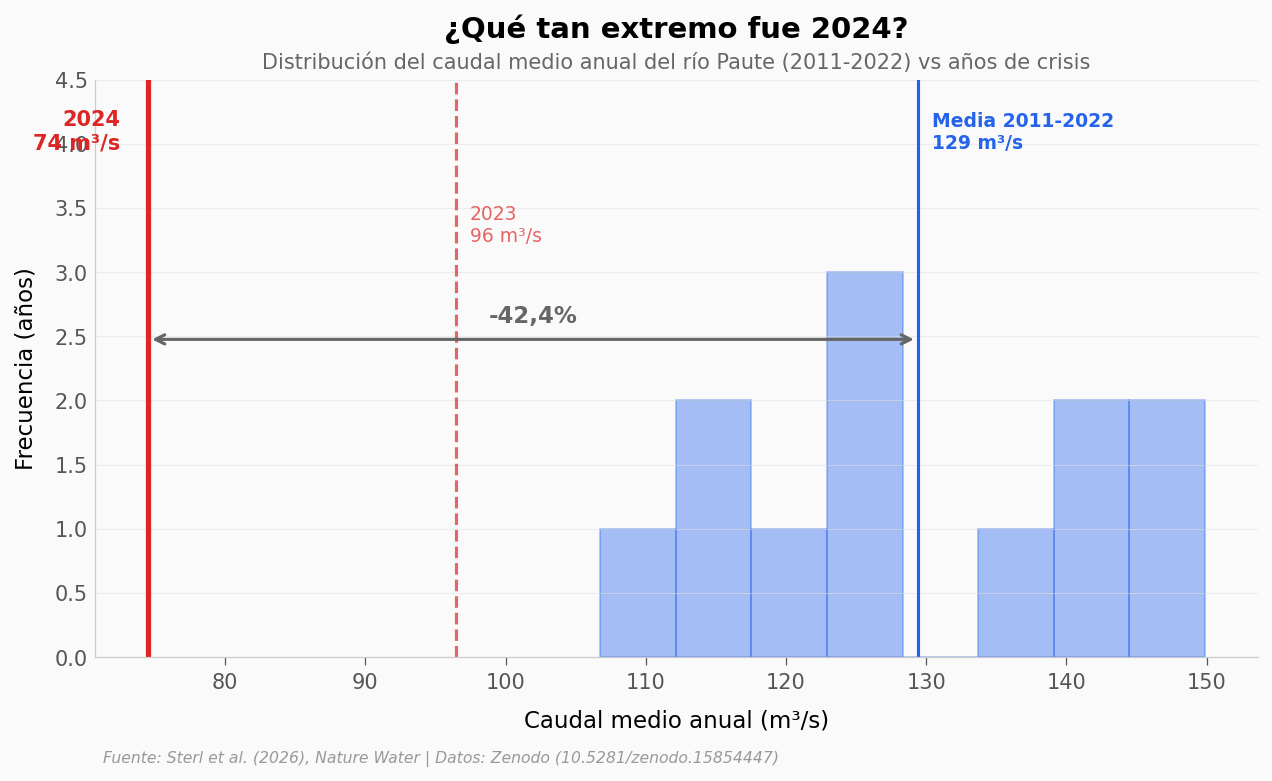

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

data = df_anual[df_anual.year <= HIST_FIN].mean_inflow_m3s.values
media = np.mean(data)
valor_2024 = df_anual[df_anual.year == ANIO_CRISIS].mean_inflow_m3s.values[0]
valor_2023 = df_anual[df_anual.year == ANIO_PREVIO].mean_inflow_m3s.values[0]

n, bins, patches = ax.hist(data, bins=8, color=COLOR_HIDRO, alpha=0.4,
                           edgecolor=COLOR_HIDRO, linewidth=0.8)
y_max = n.max() * 1.5

# Media histórica
ax.axvline(x=media, color=COLOR_HIDRO, linewidth=1.5, linestyle='-')
ax.text(media + 1, y_max * 0.88, f'Media 2011-2022\n{media:.0f} m³/s',
        fontsize=9, color=COLOR_HIDRO, fontweight='bold')

# 2023
ax.axvline(x=valor_2023, color=COLOR_ALERTA, linewidth=1.5, linestyle='--', alpha=0.7)
ax.text(valor_2023 + 1, y_max * 0.72, f'2023\n{valor_2023:.0f} m³/s',
        fontsize=9, color=COLOR_ALERTA, alpha=0.7)

# 2024
ax.axvline(x=valor_2024, color=COLOR_ALERTA, linewidth=2.5)
ax.text(valor_2024 - 2, y_max * 0.88, f'2024\n{valor_2024:.0f} m³/s',
        fontsize=10, color=COLOR_ALERTA, fontweight='bold', ha='right')

# Flecha bidireccional
ax.annotate('', xy=(valor_2024, y_max * 0.55), xytext=(media, y_max * 0.55),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((media + valor_2024) / 2, y_max * 0.58, f'-42,4%',
        fontsize=11, fontweight='bold', color='#666666', ha='center')

ax.set_ylim(0, y_max)
ax.set_xlabel('Caudal medio anual (m³/s)', fontsize=11)
ax.set_ylabel('Frecuencia (años)', fontsize=11)
ax.set_title('¿Qué tan extremo fue 2024?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Distribución del caudal medio anual del río Paute (2011-2022) vs años de crisis',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/anomalia_caudal_2024.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| El caudal del Paute cayó drásticamente en 2024 | ✅ | Media anual 74,5 m³/s vs histórica 129,4 m³/s (-42,4%, d = -3,91, n = 12 años históricos). 8 meses con déficit >30% |
| La sequía empezó en 2023 | ✅ | Media 2023: 96,5 m³/s (-25,5% vs histórica). Dos años consecutivos por debajo del mínimo histórico |
| Los factores de capacidad de solar/eólica no varían entre años | ✅ | El dataset usa un año meteorológico típico (TMY); la variación inter-anual es <1% (artefacto de promediar meses con distinto número de días en años bisiestos). En la realidad habría algo más de variación, pero el argumento del paper se sostiene |
| Eólica y solar podrían compensar parcialmente el déficit | ⚠️ | Los datos de CF muestran que las renovables generarían ~388-548 MW promedio combinados en los meses críticos (con oct-nov significativamente más bajos que ago-sep). Pero la compensación real depende del modelo REVUB (simulación), no solo de los CFs |
| Crédito de capacidad indirecto del 59% | ⚠️ | Resultado del modelo REVUB, no reproducible con los datos de entrada solamente. El paper reporta 59% (rango 50-65%) |

> **Limitaciones:** (1) Solo tenemos los datos de entrada del modelo REVUB, no sus resultados. Las simulaciones de generación y niveles de embalse las hizo el modelo original. (2) Los CFs usan un año meteorológico típico — en la realidad, viento y sol también varían año a año, aunque mucho menos que el caudal. (3) La aproximación MW ∝ caudal es simplificada; la relación real depende de la cabeza hidráulica y la curva de eficiencia de cada turbina. (4) n = 14 años es una serie hidrológica corta para establecer estadísticas robustas.

## Ahora tú

1. **¿Qué pasa si solo inviertes en solar?** Cambia `CAPACIDAD_EOLICA_MW = 0` y duplica `CAPACIDAD_SOLAR_MW = 1226`. ¿Cubre el déficit nocturno? (Pista: la solar tiene CF = 0% de noche)

2. **¿Cuál habría sido el peor mes histórico SIN la sequía de 2024?** Busca en `df_paute` el mes con menor caudal excluyendo 2023-2024. ¿Cuánto peor fue 2024?

3. **¿Es el Paute representativo?** Los datos incluyen 6 ríos distintos. Prueba a graficar otro río cargando `caudal_total_mensual.csv` — ¿la sequía de 2024 afectó a todos por igual?

In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿Cuánta capacidad renovable se necesita para cubrir TODO el déficit
# de los 4 peores meses de 2024?

meses_crisis = [8, 9, 10, 11]  # Ago, Sep, Oct, Nov

for m in meses_crisis:
    hist_m = df_paute[(df_paute.year <= HIST_FIN) & (df_paute.month == m)].inflow_m3s.mean()
    val_2024 = df_paute[(df_paute.year == ANIO_CRISIS) & (df_paute.month == m)].inflow_m3s.values[0]
    deficit_mw = (1 - val_2024 / hist_m) * 1757  # MW perdidos (aproximación)
    
    wind_cf_m = df_re[df_re.month == m].wind_cf.mean()
    solar_cf_m = df_re[df_re.month == m].solar_cf.mean()
    cf_combinado = (wind_cf_m + solar_cf_m) / 2  # CF promedio solar+eólica 50:50
    
    capacidad_necesaria = deficit_mw / cf_combinado if cf_combinado > 0 else float('inf')
    
    nombre = MESES[m-1]
    print(f"{nombre} 2024: déficit ≈ {deficit_mw:.0f} MW | "
          f"CF combinado: {cf_combinado*100:.1f}% | "
          f"Capacidad necesaria: {capacidad_necesaria:.0f} MW")

print(f"\nPara contexto: escenario S4 del paper = {CAPACIDAD_SOLAR_MW + CAPACIDAD_EOLICA_MW} MW total")

Ago 2024: déficit ≈ 1114 MW | CF combinado: 44.7% | Capacidad necesaria: 2491 MW
Sep 2024: déficit ≈ 1047 MW | CF combinado: 41.5% | Capacidad necesaria: 2522 MW
Oct 2024: déficit ≈ 1047 MW | CF combinado: 33.8% | Capacidad necesaria: 3100 MW
Nov 2024: déficit ≈ 1172 MW | CF combinado: 31.6% | Capacidad necesaria: 3707 MW

Para contexto: escenario S4 del paper = 1226 MW total


---

## Créditos

- **Paper:** Sterl, S., Pineda, L.E., Masson, T. et al. *Variable renewables fortify Ecuador's power system against recurrences of drought-driven energy crises.* Nature Water (2026). DOI: [10.1038/s44221-026-00617-w](https://doi.org/10.1038/s44221-026-00617-w)
- **Datos:** REVUB model input files — [Zenodo (10.5281/zenodo.15854447)](https://doi.org/10.5281/zenodo.15854447)
- **Licencia datos:** Creative Commons Attribution 4.0 International
- **Repo:** [Ciencia a Mordiscos — El Lab](https://github.com/Ciencia-a-Mordiscos/lab)